# NB03: statistical inference and robustness

**Purpose:** quantify uncertainty around observed draft-slot associations and check whether the core result is stable across seasons.

**Pipeline:** prepared panel -> league-clustered bootstrap -> season-stratified sensitivity checks -> inference artifacts.

**Inputs:** `data/processed/analysis_panel.csv`. **Outputs:** `artifacts/inference_slot_effects.csv`, `artifacts/inference_season_sensitivity.csv`, and three interval charts.

**Run:** execute after NB02.

**Locked definitions:** this is descriptive statistical inference, not predictive modeling. The bootstrap resamples complete league-seasons.

**Gate table:** 12 rows per league-season; pooled top-six rate equals 0.5; pooled top-scorer rate equals 1/12.


### What this cell does

- Loads 3,641 complete league-season blocks for cluster-aware inference.


In [1]:
# CELL [1 load-league-blocks]
import csv, json, random
from collections import defaultdict
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
with (ROOT / 'data/processed/analysis_panel.csv').open(encoding='utf-8') as handle:
    rows = list(csv.DictReader(handle))
for row in rows:
    row['draft_slot'] = int(row['draft_slot']); row['season'] = int(row['season'])
    for field in ['points_zscore', 'top_6_points', 'top_regular_season_scorer']:
        row[field] = float(row[field])
blocks = defaultdict(list)
for row in rows: blocks[(row['league_id'], row['season'])].append(row)
if any(len(block) != 12 for block in blocks.values()): raise RuntimeError('Inference gate failed: incomplete league block')
print({'league_blocks': len(blocks), 'team_seasons': len(rows), 'seasons': sorted({r['season'] for r in rows})})


{'league_blocks': 3641, 'team_seasons': 43692, 'seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]}


### Interpreting the output

- The panel contains 3,641 complete league-seasons and 43,692 team-seasons across 2018 to 2025.
- No incomplete blocks were found, so resampling leagues preserves all 12 draft-slot observations.
- This supports cluster-aware uncertainty intervals.
- It does not make the public-network sample representative of all fantasy leagues.


### What this cell does

- Estimates each slot relative to the all-slot baseline using 2,000 league-clustered bootstrap draws.


In [2]:
# CELL [2 clustered-bootstrap]
OUTCOMES = ['points_zscore', 'top_6_points', 'top_regular_season_scorer']
BASELINES = {'points_zscore': 0.0, 'top_6_points': 0.5, 'top_regular_season_scorer': 1 / 12}
block_values = list(blocks.values())
def slot_means(sample):
    total = {outcome: [0.0] * 12 for outcome in OUTCOMES}
    for block in sample:
        for row in block:
            for outcome in OUTCOMES: total[outcome][row['draft_slot'] - 1] += row[outcome]
    return {outcome: [value / len(sample) for value in values] for outcome, values in total.items()}
observed = slot_means(block_values); rng = random.Random(20260811)
draws = {outcome: [[] for _ in range(12)] for outcome in OUTCOMES}
for _ in range(2000):
    estimate = slot_means([block_values[rng.randrange(len(block_values))] for _ in range(len(block_values))])
    for outcome in OUTCOMES:
        for slot in range(12): draws[outcome][slot].append(estimate[outcome][slot] - BASELINES[outcome])
effects = []
for outcome in OUTCOMES:
    for slot in range(12):
        values = sorted(draws[outcome][slot])
        effects.append({'outcome': outcome, 'draft_slot': slot + 1, 'estimate_minus_baseline': observed[outcome][slot] - BASELINES[outcome], 'ci_95_low': values[49], 'ci_95_high': values[1949], 'baseline': BASELINES[outcome], 'n_league_seasons': len(block_values)})
print({'bootstrap_replicates': 2000, 'slot_1_top_six_effect': round(effects[12]['estimate_minus_baseline'], 4), 'slot_4_top_six_effect': round(effects[15]['estimate_minus_baseline'], 4)})


{'bootstrap_replicates': 2000, 'slot_1_top_six_effect': -0.0394, 'slot_4_top_six_effect': 0.028}


### Interpreting the output

- Slot 1 is 3.94 percentage points below the 50% top-six baseline, while slot 4 is 2.80 points above it.
- The observed slot 4 minus slot 1 gap is 6.74 percentage points across 3,641 league-seasons.
- The next charts show uncertainty under complete-league resampling.
- This gap does not isolate why slot 4 outperforms slot 1 or establish causality.


### What this cell does

- Defines a dependency-free SVG interval chart and renders points-zscore effects.


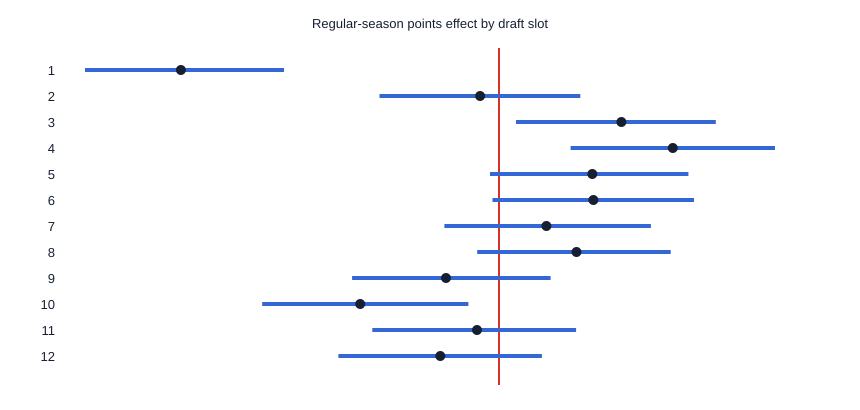

In [3]:
# CELL [3 points-interval-chart]
def interval_chart(path, title, outcome):
    selected = [r for r in effects if r['outcome'] == outcome]
    lo = min(r['ci_95_low'] for r in selected); hi = max(r['ci_95_high'] for r in selected); span = hi - lo or 1.0
    x = lambda value: 85 + 690 * (value - lo) / span
    marks = []
    for i, row in enumerate(selected):
        y = 70 + i * 26
        marks.append(f'<text x="55" y="{y+5}" text-anchor="end">{row["draft_slot"]}</text><line x1="{x(row["ci_95_low"]):.1f}" y1="{y}" x2="{x(row["ci_95_high"]):.1f}" y2="{y}" stroke="#3367d6" stroke-width="4"/><circle cx="{x(row["estimate_minus_baseline"]):.1f}" cy="{y}" r="5" fill="#172033"/>')
    marks_svg = ''.join(marks); zero = x(0.0)
    svg = f'<svg xmlns="http://www.w3.org/2000/svg" width="860" height="410"><style>text{{font-family:Arial;font-size:13px;fill:#172033}}</style><text x="430" y="28" text-anchor="middle" font-size="20">{title}</text><line x1="{zero:.1f}" y1="48" x2="{zero:.1f}" y2="385" stroke="#d93025" stroke-width="2"/>{marks_svg}</svg>'
    path.write_text(svg, encoding='utf-8')
    try:
        from IPython.display import SVG, display
        display(SVG(filename=str(path)))
    except ImportError: print(path)
interval_chart(ROOT / 'artifacts/inference_01_points_intervals.svg', 'Regular-season points effect by draft slot', 'points_zscore')


### Interpreting the output

- Slot 4 leads at +0.056 points z-score units, with a 95% interval from +0.023 to +0.089. Slot 3 is also above zero at +0.039, with an interval from +0.005 to +0.070.
- Slot 1 is lowest at -0.102, with an interval from -0.133 to -0.069. Slot 10 is also below zero at -0.045.
- The pooled points pattern favors early-middle slots, especially slot 4.
- It does not show that the ordering is stable in every season.


### What this cell does

- Renders top-six regular-season scoring effects with their bootstrap intervals.


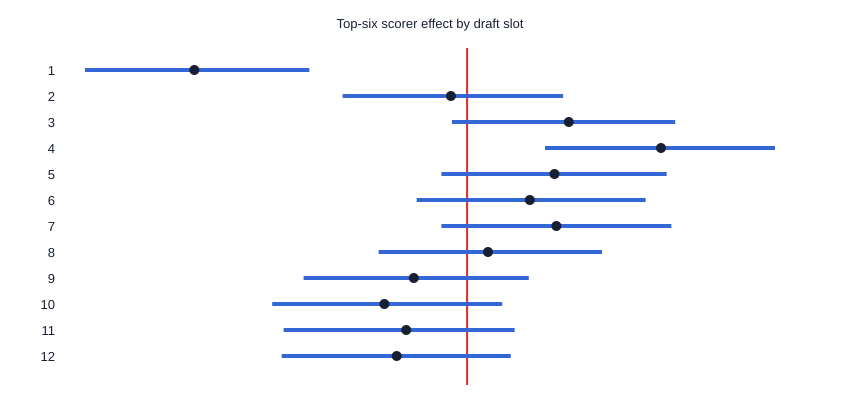

In [4]:
# CELL [4 top-six-interval-chart]
interval_chart(ROOT / 'artifacts/inference_02_top_six_intervals.svg', 'Top-six scorer effect by draft slot', 'top_6_points')


### Interpreting the output

- Slot 4 is 2.80 percentage points above the 50% baseline, with a 95% interval from +1.13 to +4.45 points.
- Slot 1 is 3.94 points below baseline, with an interval from -5.52 to -2.28 points.
- The slot 4 minus slot 1 top-six gap is 6.74 points in the 3,641-league sample.
- It does not prove draft slot alone caused the difference.


### What this cell does

- Renders outright regular-season top-scorer effects with their bootstrap intervals.


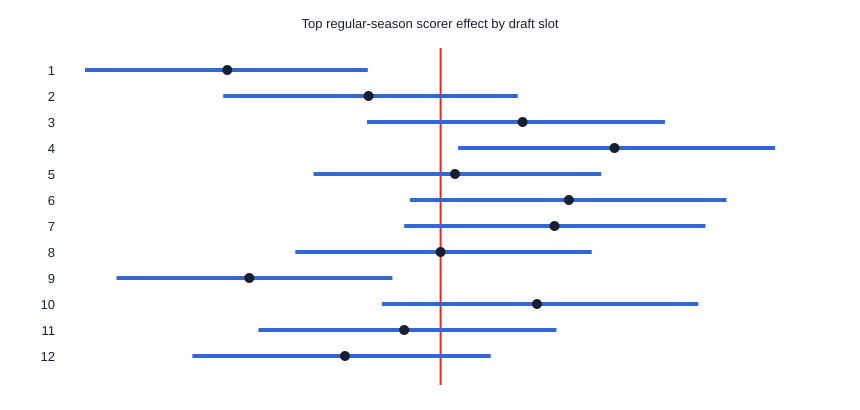

In [5]:
# CELL [5 top-scorer-interval-chart]
interval_chart(ROOT / 'artifacts/inference_03_top_scorer_intervals.svg', 'Top regular-season scorer effect by draft slot', 'top_regular_season_scorer')


### Interpreting the output

- Slot 4 leads at 9.38%, which is 1.05 percentage points above the 8.33% baseline. Its 95% effect interval runs from +0.11 to +2.02 points.
- Slot 1 is lowest at 7.05%, or 1.29 points below baseline, with an interval from -2.14 to -0.44 points.
- The top-scorer outcome agrees directionally with the points and top-six results.
- It does not prove slot 4 is optimal for every scoring or roster format.


### What this cell does

- Checks the slot-1 versus slot-4 top-six gap separately in each season.


In [6]:
# CELL [6 season-sensitivity]
sensitivity = []
for season in sorted({r['season'] for r in rows}):
    season_rows = [r for r in rows if r['season'] == season]
    rate_1 = sum(r['top_6_points'] for r in season_rows if r['draft_slot'] == 1) / (len(season_rows) / 12)
    rate_4 = sum(r['top_6_points'] for r in season_rows if r['draft_slot'] == 4) / (len(season_rows) / 12)
    sensitivity.append({'season': season, 'slot_1_top_6_rate': rate_1, 'slot_4_top_6_rate': rate_4, 'slot_4_minus_slot_1': rate_4 - rate_1})
with (ROOT / 'artifacts/inference_season_sensitivity.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(sensitivity[0])); writer.writeheader(); writer.writerows(sensitivity)
print(sensitivity)


[{'season': 2018, 'slot_1_top_6_rate': 0.5555555555555556, 'slot_4_top_6_rate': 0.5555555555555556, 'slot_4_minus_slot_1': 0.0}, {'season': 2019, 'slot_1_top_6_rate': 0.48134328358208955, 'slot_4_top_6_rate': 0.48880597014925375, 'slot_4_minus_slot_1': 0.007462686567164201}, {'season': 2020, 'slot_1_top_6_rate': 0.5149863760217984, 'slot_4_top_6_rate': 0.4986376021798365, 'slot_4_minus_slot_1': -0.016348773841961928}, {'season': 2021, 'slot_1_top_6_rate': 0.47912524850894633, 'slot_4_top_6_rate': 0.47813121272365805, 'slot_4_minus_slot_1': -0.000994035785288283}, {'season': 2022, 'slot_1_top_6_rate': 0.4448669201520912, 'slot_4_top_6_rate': 0.596958174904943, 'slot_4_minus_slot_1': 0.15209125475285173}, {'season': 2023, 'slot_1_top_6_rate': 0.47587354409317806, 'slot_4_top_6_rate': 0.519134775374376, 'slot_4_minus_slot_1': 0.043261231281197965}, {'season': 2024, 'slot_1_top_6_rate': 0.3720472440944882, 'slot_4_top_6_rate': 0.5308398950131233, 'slot_4_minus_slot_1': 0.15879265091863515}

### Interpreting the output

- Across eight seasons, slot 4 beats slot 1 in five, ties in 2018, and trails in 2020 and 2021.
- The gap is largest in 2022 at +15.21 percentage points and 2024 at +15.88 points. It is +4.33 in 2023 and +3.25 in 2025.
- The pooled advantage is not a stable year-by-year law; two recent seasons contribute much of its size.
- This check does not adjust for scoring format, manager quality, or selection into the public network.


### What this cell does

- Saves inference artifacts and verifies panel-level outcome accounting.


In [7]:
# CELL [7 save-and-evaluate]
with (ROOT / 'artifacts/inference_slot_effects.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(effects[0])); writer.writeheader(); writer.writerows(effects)
evaluation = {'league_seasons': len(block_values), 'top_6_baseline_observed': sum(r['top_6_points'] for r in rows) / len(rows), 'top_scorer_baseline_observed': sum(r['top_regular_season_scorer'] for r in rows) / len(rows), 'bootstrap_replicates': 2000}
if abs(evaluation['top_6_baseline_observed'] - 0.5) > 1e-12 or abs(evaluation['top_scorer_baseline_observed'] - 1/12) > 1e-12: raise RuntimeError('Inference accounting gate failed')
(ROOT / 'artifacts/inference_evaluation.json').write_text(json.dumps(evaluation, indent=2))
print(json.dumps(evaluation, indent=2))


{
  "league_seasons": 3641,
  "top_6_baseline_observed": 0.5,
  "top_scorer_baseline_observed": 0.08333333333333348,
  "bootstrap_replicates": 2000
}


### Interpreting the output

- The pooled baselines are exactly 0.50 for top-six and 0.0833 for top scorer, as required by the fractional-credit design.
- The accounting gate passed on all 3,641 league-seasons.
- The saved inference tables therefore correspond to a coherent balanced panel.
- It does not validate the external representativeness of the sample.


## Conclusion

- Within 3,641 public Sleeper league-seasons from 2018 through 2025, slot 4 has the strongest pooled points z-score, top-six rate, and top-scorer rate; slot 1 has the weakest values on all three.
- League-cluster intervals exclude the baseline for both slots on those outcomes, but the slot 4 minus slot 1 gap changes sign in two of eight seasons.
- NB03 writes inference tables and three interval charts. NB04 may run after all accounting gates pass.
- These results are descriptive and do not establish a universal causal draft-order effect.
